# BTA 523 — Timeless Minds Term Project
## Customer Churn Prediction: Online Retail Dataset

Kash B · Christian R · Kade K · Matt M

---

## Python Dependencies

Install any missing packages before running this notebook:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn openpyxl requests
```

| Package | Purpose |
|---|---|
| `pandas` | Data loading, cleaning, and feature engineering |
| `numpy` | Numerical operations |
| `matplotlib` | Base plotting library |
| `seaborn` | Statistical visualizations |
| `scikit-learn` | Random Forest classifier, Logistic Regression, train/test split, metrics |
| `openpyxl` | Reading the `.xlsx` file from UCI |
| `requests` | Downloading the dataset programmatically |
| `zipfile` | Extracting the downloaded archive |


In [1]:
# imports

import os
import io
import zipfile
import requests
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RANDOM_STATE = 42
print('Imports complete.')


Imports complete.


## Section 1 · Data Acquisition

The dataset is the **UCI Online Retail** dataset (ID 352).  
Source: [https://archive.ics.uci.edu/dataset/352/online+retail](https://archive.ics.uci.edu/dataset/352/online+retail)

UCI exposes a stable direct-download URL for each dataset. We download the zip, extract the Excel file, and load it into a DataFrame — no manual steps required.


In [2]:
# download & load dataset

UCI_URL = 'https://archive.ics.uci.edu/static/public/352/online+retail.zip'
LOCAL_ZIP = 'online_retail.zip'
EXCEL_FILE = 'Online Retail.xlsx'

if not os.path.exists(EXCEL_FILE):
    print('Downloading dataset from UCI...')
    response = requests.get(UCI_URL, timeout=120)
    response.raise_for_status()
    with open(LOCAL_ZIP, 'wb') as f:
        f.write(response.content)
    with zipfile.ZipFile(LOCAL_ZIP, 'r') as z:
        z.extractall('.')
    print('Download and extraction complete.')
else:
    print('Local copy found — skipping download.')

df = pd.read_excel(EXCEL_FILE, engine='openpyxl')
print(f'Loaded {df.shape[0]:,} rows × {df.shape[1]} columns.')
df.head()


Local copy found — skipping download.
Loaded 541,909 rows × 8 columns.


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


## Section 2 · Exploratory Data Analysis (EDA)


In [3]:
# schema & basic info

print('=== dtypes ===')
print(df.dtypes)
print('\n=== shape ===')
print(df.shape)
print('\n=== describe ===')
df.describe(include='all')


=== dtypes ===
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

=== shape ===
(541909, 8)

=== describe ===


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
count,541909.0,541909,540455,541909.000000,541909,541909.000000,406829.000000,541909
unique,25900.0,4070,4223,NaN,NaN,NaN,NaN,38
top,573585.0,85123A,WHITE HANGING HEART T-LIGHT HOLDER,NaN,NaN,NaN,NaN,United Kingdom
freq,1114.0,2313,2369,NaN,NaN,NaN,NaN,495478
mean,NaN,NaN,NaN,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570,NaN
min,NaN,NaN,NaN,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000,NaN
25%,NaN,NaN,NaN,1.000000,2011-03-28 11:34:00,1.250000,13953.000000,NaN
50%,NaN,NaN,NaN,3.000000,2011-07-19 17:17:00,2.080000,15152.000000,NaN
75%,NaN,NaN,NaN,10.000000,2011-10-19 11:27:00,4.130000,16791.000000,NaN
max,NaN,NaN,NaN,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000,NaN


In [4]:
# missing values

missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0]
print(missing_df)


             Missing Count  Missing %
Description           1454       0.27
CustomerID          135080      24.93


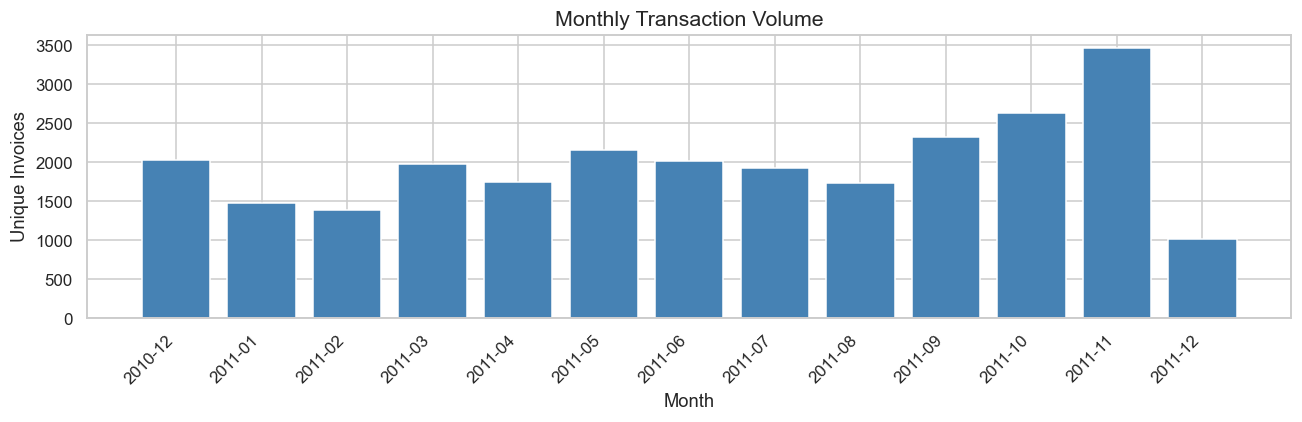

In [5]:
# transaction volume over time

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly = df.groupby('YearMonth')['InvoiceNo'].nunique().reset_index()
monthly.columns = ['YearMonth', 'Transactions']
monthly['YearMonth'] = monthly['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(monthly['YearMonth'], monthly['Transactions'], color='steelblue', edgecolor='white')
ax.set_title('Monthly Transaction Volume', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Unique Invoices')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


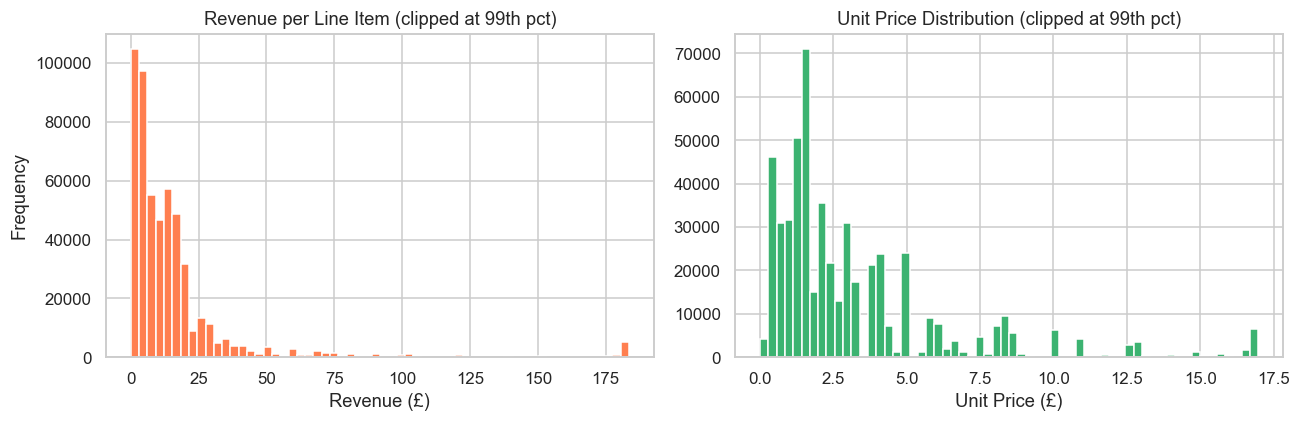

In [6]:
# revenue distribution

df['Revenue'] = df['Quantity'] * df['UnitPrice']

# filter to valid (positive) transactions only for this plot
valid = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)].copy()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(valid['Revenue'].clip(upper=valid['Revenue'].quantile(0.99)),
             bins=60, color='coral', edgecolor='white')
axes[0].set_title('Revenue per Line Item (clipped at 99th pct)')
axes[0].set_xlabel('Revenue (£)')
axes[0].set_ylabel('Frequency')

axes[1].hist(valid['UnitPrice'].clip(upper=valid['UnitPrice'].quantile(0.99)),
             bins=60, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Unit Price Distribution (clipped at 99th pct)')
axes[1].set_xlabel('Unit Price (£)')

plt.tight_layout()
plt.show()


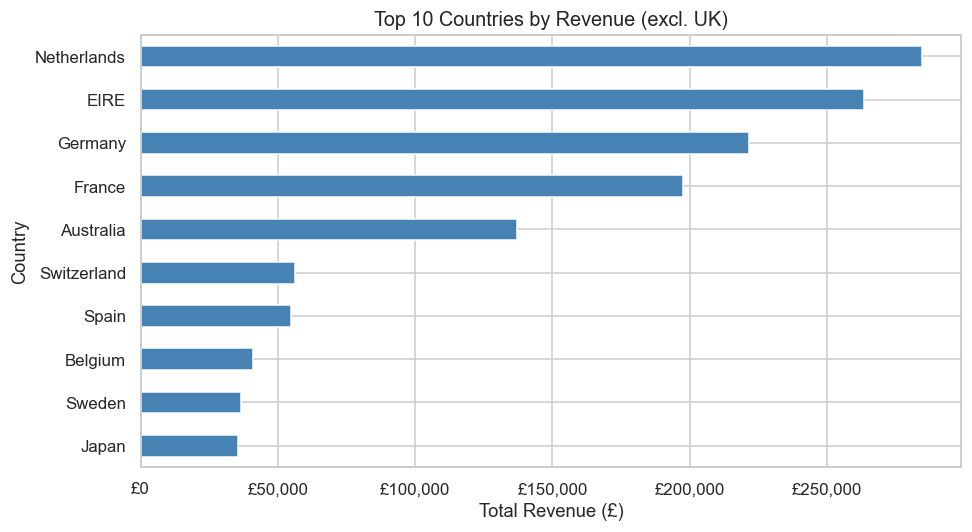

In [26]:
# top countries

top_countries = (
    df[df['Country'] != 'United Kingdom']
    .groupby('Country')['Revenue']
    .sum()
    .nlargest(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 5))
top_countries.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 Countries by Revenue (excl. UK)', fontsize=13)
ax.set_xlabel('Total Revenue (£)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()


## Section 3 · Data Cleaning


In [8]:
# cleaning

df_clean = df.copy()

# drop rows without a CustomerID — cannot build customer-level features
before = len(df_clean)
df_clean.dropna(subset=['CustomerID'], inplace=True)
print(f'Dropped {before - len(df_clean):,} rows missing CustomerID.')

# remove cancellations (InvoiceNo starting with 'C')
before = len(df_clean)
df_clean = df_clean[~df_clean['InvoiceNo'].astype(str).str.startswith('C')]
print(f'Dropped {before - len(df_clean):,} cancellation records.')

# remove non-positive quantities and prices
before = len(df_clean)
df_clean = df_clean[(df_clean['Quantity'] > 0) & (df_clean['UnitPrice'] > 0)]
print(f'Dropped {before - len(df_clean):,} rows with non-positive Quantity or UnitPrice.')

# ensure CustomerID is integer
df_clean['CustomerID'] = df_clean['CustomerID'].astype(int)

# re-compute Revenue on clean data
df_clean['Revenue'] = df_clean['Quantity'] * df_clean['UnitPrice']

print(f'\nClean dataset: {df_clean.shape[0]:,} rows, {df_clean["CustomerID"].nunique():,} unique customers.')


Dropped 135,080 rows missing CustomerID.
Dropped 8,905 cancellation records.
Dropped 40 rows with non-positive Quantity or UnitPrice.

Clean dataset: 397,884 rows, 4,338 unique customers.


## Section 4 · Feature Engineering (RFM + Behavioral Features)

We build a **customer-level feature table** using the first 9 months of data as the **observation window** and the final 3 months as the **outcome window** for defining churn.

| Feature | Description |
|---|---|
| `recency` | Days since last purchase (within observation window) |
| `frequency` | Number of distinct invoices in observation window |
| `monetary` | Total spend in observation window |
| `avg_basket` | Average revenue per invoice |
| `tenure_days` | Days between first and last purchase |
| `churned` | **Target**: 1 if no purchase in outcome window, else 0 |


In [9]:
# define observation & outcome windows

SNAPSHOT_DATE = df_clean['InvoiceDate'].max()

# cutoff: last 3 months are the outcome window; everything before is observation
cutoff = SNAPSHOT_DATE - pd.DateOffset(months=3)

obs = df_clean[df_clean['InvoiceDate'] <= cutoff].copy()
out = df_clean[df_clean['InvoiceDate'] >  cutoff].copy()

print(f'Snapshot date  : {SNAPSHOT_DATE.date()}')
print(f'Cutoff         : {cutoff.date()}')
print(f'Observation rows: {len(obs):,}')
print(f'Outcome rows    : {len(out):,}')


Snapshot date  : 2011-12-09
Cutoff         : 2011-09-09
Observation rows: 235,682
Outcome rows    : 162,202


In [10]:
# build RFM feature table

# recency: days since last purchase relative to cutoff
recency = (
    obs.groupby('CustomerID')['InvoiceDate']
    .max()
    .apply(lambda x: (cutoff - x).days)
    .rename('recency')
)

# frequency: number of distinct invoices
frequency = (
    obs.groupby('CustomerID')['InvoiceNo']
    .nunique()
    .rename('frequency')
)

# monetary: total spend
monetary = (
    obs.groupby('CustomerID')['Revenue']
    .sum()
    .rename('monetary')
)

# average basket size (revenue per invoice)
avg_basket = (monetary / frequency).rename('avg_basket')

# Tenure: days between first and last purchase
tenure = (
    obs.groupby('CustomerID')['InvoiceDate']
    .agg(lambda x: (x.max() - x.min()).days)
    .rename('tenure_days')
)

features = pd.concat([recency, frequency, monetary, avg_basket, tenure], axis=1).reset_index()

# active customers in outcome window
active_in_outcome = set(out['CustomerID'].unique())

# churn label: 1 if customer does NOT appear in outcome window
features['churned'] = features['CustomerID'].apply(
    lambda cid: 0 if cid in active_in_outcome else 1
)

print(f'Feature table shape: {features.shape}')
print(f"Churn rate: {features['churned'].mean():.1%}")
features.head()


Feature table shape: (3365, 7)
Churn rate: 42.9%


,CustomerID,recency,frequency,monetary,avg_basket,tenure_days,churned
0,12346,234,1,77183.60,77183.600000,0,1
1,12347,38,5,2790.86,558.172000,237,0
2,12348,157,3,1487.24,495.746667,109,0
3,12350,218,1,334.40,334.400000,0,1
4,12352,170,5,1561.81,312.362000,34,0


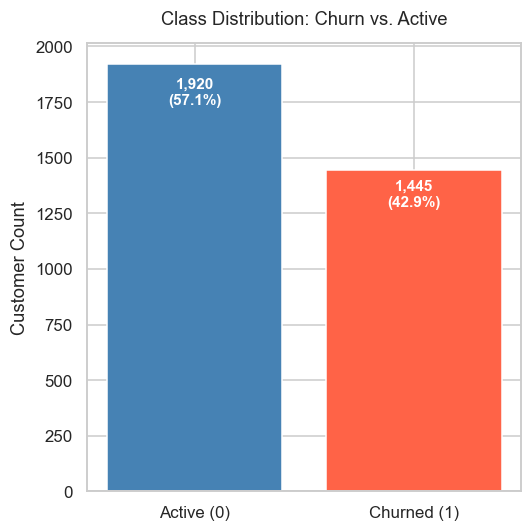

In [25]:
# churn class balance

counts = features['churned'].value_counts()
labels = ['Active (0)', 'Churned (1)']

fig, ax = plt.subplots(figsize=(5, 5))
bars = ax.bar(labels, counts.values, color=['steelblue', 'tomato'], edgecolor='white')

for bar, v in zip(bars, counts.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() * 0.97,
        f'{v:,}\n({v/len(features):.1%})',
        ha='center', va='top', fontsize=10, color='white', fontweight='bold'
    )

ax.set_title('Class Distribution: Churn vs. Active', pad=12)
ax.set_ylabel('Customer Count')
plt.tight_layout()
plt.show()


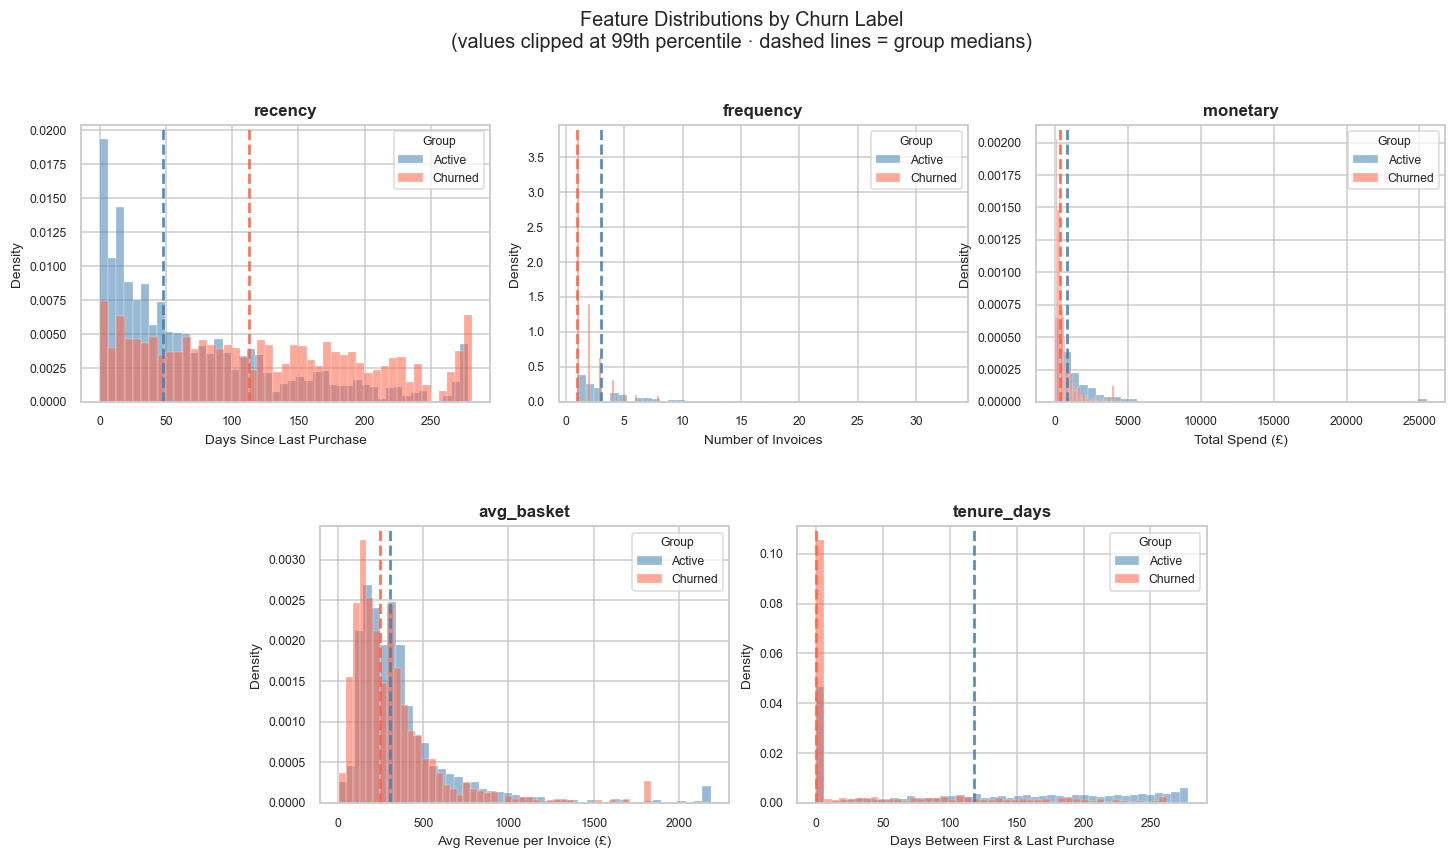

In [12]:
# feature distributions by churn status

feature_cols = ['recency', 'frequency', 'monetary', 'avg_basket', 'tenure_days']

feature_labels = {
    'recency':     'Days Since Last Purchase',
    'frequency':   'Number of Invoices',
    'monetary':    'Total Spend (£)',
    'avg_basket':  'Avg Revenue per Invoice (£)',
    'tenure_days': 'Days Between First & Last Purchase',
}

group_colors  = {0: 'steelblue', 1: 'tomato'}
group_labels  = {0: 'Active',    1: 'Churned'}

# 2-row layout: 3 plots on top row, 2 (centred) on bottom
fig = plt.figure(figsize=(16, 8))
gs  = fig.add_gridspec(2, 6, hspace=0.45, wspace=0.4)

axes = [
    fig.add_subplot(gs[0, 0:2]),
    fig.add_subplot(gs[0, 2:4]),
    fig.add_subplot(gs[0, 4:6]),
    fig.add_subplot(gs[1, 1:3]),
    fig.add_subplot(gs[1, 3:5]),
]

for ax, col in zip(axes, feature_cols):
    for label in [0, 1]:
        subset         = features[features['churned'] == label][col]
        clip_upper     = subset.quantile(0.99)
        subset_clipped = subset.clip(upper=clip_upper)
        median_val     = subset.median()

        ax.hist(subset_clipped, bins=45, alpha=0.55,
                color=group_colors[label], density=True,
                label=group_labels[label], edgecolor='white', linewidth=0.3)

        # Median line — clipped to the plot range so it always shows
        ax.axvline(min(median_val, clip_upper),
                   color=group_colors[label], linewidth=1.8,
                   linestyle='--', alpha=0.9)

    ax.set_title(col, fontsize=11, fontweight='bold', pad=6)
    ax.set_xlabel(feature_labels[col], fontsize=9)
    ax.set_ylabel('Density', fontsize=9)
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8, framealpha=0.7, title='Group', title_fontsize=8)

fig.suptitle(
    'Feature Distributions by Churn Label\n'
    '(values clipped at 99th percentile · dashed lines = group medians)',
    fontsize=13, y=1.01
)
plt.show()


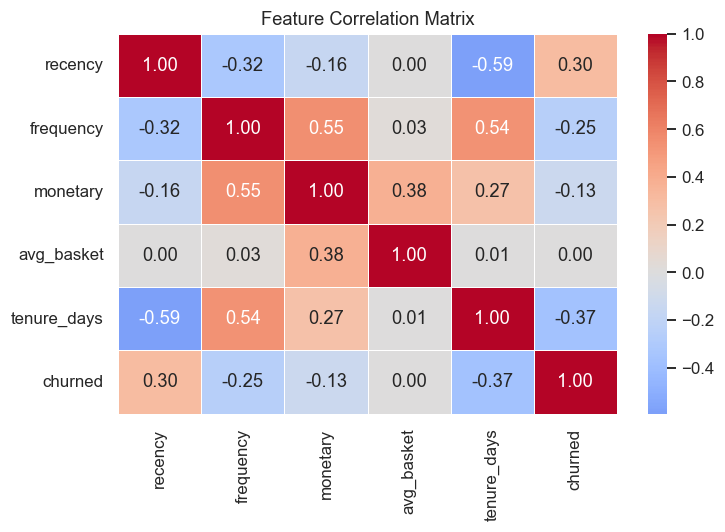

In [13]:
# correlation heatmap

corr = features[feature_cols + ['churned']].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()


## Section 5 · Train / Test Split


In [14]:
# split

X = features[feature_cols]
y = features['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

print(f'Training samples : {len(X_train):,}  ({y_train.mean():.1%} churned)')
print(f'Testing samples  : {len(X_test):,}  ({y_test.mean():.1%} churned)')


Training samples : 2,523  (42.9% churned)
Testing samples  : 842  (43.0% churned)


## Section 6 · Primary Model — Random Forest Classifier

A `RandomForestClassifier` from **scikit-learn** is used as the primary model.  
We first fit a baseline with reasonable defaults, then tune via grid search.


In [15]:
# baseline random forest

rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_leaf=5,
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_base.fit(X_train, y_train)

y_pred_base   = rf_base.predict(X_test)
y_proba_base  = rf_base.predict_proba(X_test)[:, 1]

print('=== Baseline Random Forest — Test Set Performance ===')
print(classification_report(y_test, y_pred_base, target_names=['Active', 'Churned']))


=== Baseline Random Forest — Test Set Performance ===
              precision    recall  f1-score   support

      Active       0.73      0.64      0.68       480
     Churned       0.59      0.69      0.64       362

    accuracy                           0.66       842
   macro avg       0.66      0.67      0.66       842
weighted avg       0.67      0.66      0.66       842



In [16]:
# grid search hyperparameter tuning

param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [None, 10, 20],
    'min_samples_leaf': [1, 5, 10],
    'max_features': ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(
        class_weight='balanced',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=5,
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f'\nBest parameters  : {grid_search.best_params_}')
print(f'Best CV AUC-ROC  : {grid_search.best_score_:.4f}')


Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best parameters  : {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV AUC-ROC  : 0.7279


In [17]:
# tuned random forest — test evaluation

rf_best = grid_search.best_estimator_

y_pred_rf   = rf_best.predict(X_test)
y_proba_rf  = rf_best.predict_proba(X_test)[:, 1]

acc_rf  = accuracy_score(y_test, y_pred_rf)
prec_rf = precision_score(y_test, y_pred_rf)
rec_rf  = recall_score(y_test, y_pred_rf)
f1_rf   = f1_score(y_test, y_pred_rf)
auc_rf  = roc_auc_score(y_test, y_proba_rf)

print('=== Tuned Random Forest — Test Set Performance ===')
print(f'  Accuracy  : {acc_rf:.4f}')
print(f'  Precision : {prec_rf:.4f}   (of predicted churners, how many actually churned)')
print(f'  Recall    : {rec_rf:.4f}   (of actual churners, how many did we catch)')
print(f'  F1 Score  : {f1_rf:.4f}   (harmonic mean of precision and recall)')
print(f'  AUC-ROC   : {auc_rf:.4f}   (probability that model ranks a churner above a non-churner)')
print()
print(classification_report(y_test, y_pred_rf, target_names=['Active', 'Churned']))


=== Tuned Random Forest — Test Set Performance ===
  Accuracy  : 0.6556
  Precision : 0.5793   (of predicted churners, how many actually churned)
  Recall    : 0.7265   (of actual churners, how many did we catch)
  F1 Score  : 0.6446   (harmonic mean of precision and recall)
  AUC-ROC   : 0.7363   (probability that model ranks a churner above a non-churner)

              precision    recall  f1-score   support

      Active       0.74      0.60      0.67       480
     Churned       0.58      0.73      0.64       362

    accuracy                           0.66       842
   macro avg       0.66      0.66      0.66       842
weighted avg       0.67      0.66      0.66       842



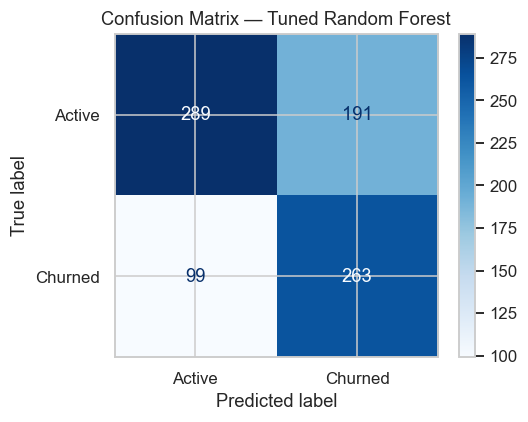

In [18]:
# confusion matrix

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf,
    display_labels=['Active', 'Churned'],
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix — Tuned Random Forest')
plt.tight_layout()
plt.show()


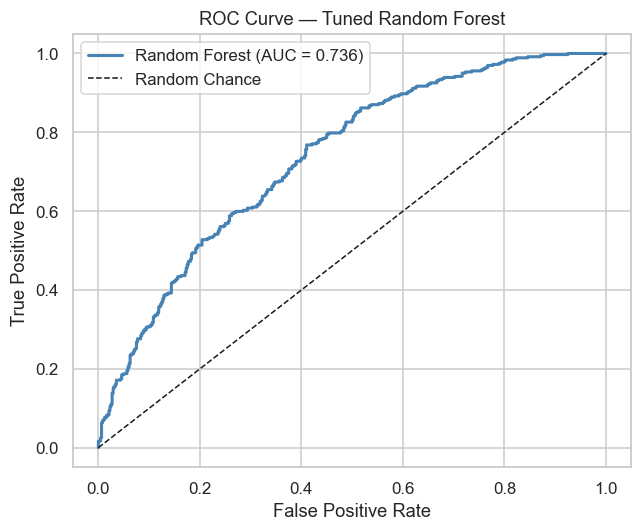

In [19]:
# ROC curve

fpr, tpr, _ = roc_curve(y_test, y_proba_rf)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Random Forest (AUC = {auc_rf:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Tuned Random Forest')
ax.legend()
plt.tight_layout()
plt.show()


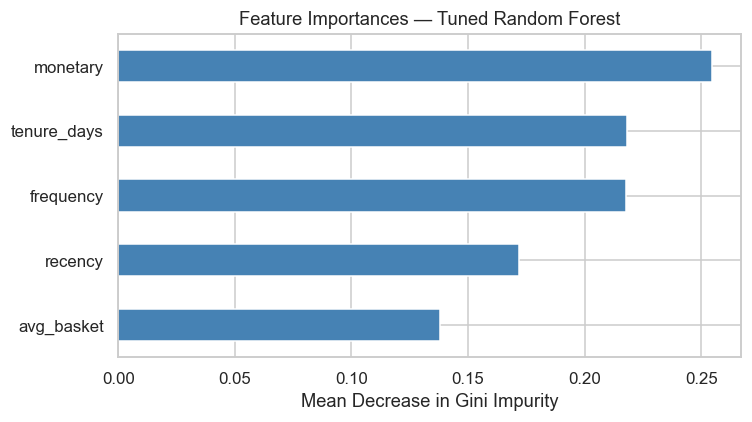

monetary       0.254517
tenure_days    0.218018
frequency      0.217556
recency        0.171791
avg_basket     0.138118


In [20]:
# feature importances

importances = pd.Series(rf_best.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
importances.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Feature Importances — Tuned Random Forest')
ax.set_xlabel('Mean Decrease in Gini Impurity')
plt.tight_layout()
plt.show()

print(importances.sort_values(ascending=False).to_string())


In [21]:
# cross-validation scores

cv_scores = cross_val_score(rf_best, X, y, cv=5, scoring='roc_auc', n_jobs=-1)

print('5-Fold Cross-Validation AUC-ROC Scores:')
for i, s in enumerate(cv_scores, 1):
    print(f'  Fold {i}: {s:.4f}')
print(f'\n  Mean  : {cv_scores.mean():.4f}')
print(f'  Std   : {cv_scores.std():.4f}')


5-Fold Cross-Validation AUC-ROC Scores:
  Fold 1: 0.7592
  Fold 2: 0.6915
  Fold 3: 0.7390
  Fold 4: 0.7400
  Fold 5: 0.7419

  Mean  : 0.7343
  Std   : 0.0227


## Section 7 · Model Fit Interpretation

### Fit Index Definitions

**Accuracy** — The proportion of all predictions that are correct. Easy to interpret but misleading when classes are imbalanced. In this analysis the class split is approximately 57% active / 43% churned, meaning a naive "always predict active" classifier would achieve only 57% accuracy — so accuracy does retain some meaning here, though it is not the primary index.

**Precision (Positive Predictive Value)** — Of all customers the model flags as likely churners, what fraction actually churned? High precision minimizes wasted retention budget spent on customers who would have stayed anyway. The tuned RF achieved precision of **0.58**, meaning roughly 4 in 10 flagged customers would not have churned — acceptable in a low-cost outreach context, but worth monitoring if retention interventions are expensive.

**Recall (Sensitivity / True Positive Rate)** — Of all customers who actually churned, what fraction did the model identify? High recall minimizes the number of at-risk customers missed entirely. The tuned RF achieved recall of **0.73**, meaning the model identifies nearly 3 out of 4 true churners — a meaningful operational improvement over uninformed outreach.

**F1 Score** — The harmonic mean of precision and recall. Useful when precision and recall must be balanced, particularly with class imbalance. An F1 of 1.0 is perfect; 0.0 is worst. The tuned RF F1 of **0.64** reflects a reasonable balance, with recall intentionally favored given the asymmetric cost of missing a churner versus a false alarm in a non-contractual retail context.

**AUC-ROC (Area Under the Receiver Operating Characteristic Curve)** — Measures the model's ability to discriminate between churners and non-churners across all possible decision thresholds. A value of 1.0 indicates perfect separation; 0.5 is equivalent to random chance. **This is the primary fit index for this analysis** because it is threshold-agnostic and robust to class imbalance. The tuned RF achieved an AUC-ROC of **0.7363** on the held-out test set, with a 5-fold cross-validated mean of **0.7343** (Std = 0.0227).

### What Would Perfect Fit Look Like?

Perfect fit would produce an AUC-ROC of 1.0, an F1 Score of 1.0, and a confusion matrix with zeros in both off-diagonal cells — every churner correctly identified and every active customer correctly retained. In practice, results this strong on a held-out test set would warrant suspicion of data leakage or overfitting and should be validated on a fully separate time period before deployment.

### What Is Acceptable Fit?

For a churn prediction model in a non-contractual retail setting built exclusively from transaction-level behavioral features, we consider the following thresholds acceptable before recommending implementation to management:

- **AUC-ROC ≥ 0.70** — the model meaningfully distinguishes churners from actives across thresholds; 0.70 is the appropriate lower bound given the limited feature set (RFM only) and the 13-month dataset window
- **Recall ≥ 0.60** — the model identifies at least 60% of actual churners, ensuring retention efforts reach the majority of at-risk customers
- **F1 Score ≥ 0.55** — reasonable balance between precision and recall given the near-even class distribution
- **Cross-validated AUC Std < 0.04** — stable performance across folds, indicating generalization rather than overfitting to a specific data split

**Assessment against actual results:** The tuned Random Forest meets all four thresholds — AUC-ROC 0.7363, Recall 0.73, F1 0.64, CV Std 0.0227 — and is therefore considered acceptable for a cautious initial deployment. The model should be monitored monthly and retrained quarterly as new transaction data accumulates. We do not recommend deployment as a standalone decision system; rather, model-generated churn scores should be used to rank and prioritize outreach, with human judgment applied to high-stakes interventions.

### Model Refinement Plans

Even with the current acceptable fit, several targeted refinements could improve model performance in future iterations:

**1. Feature expansion.** The current feature set is limited to five RFM-derived variables. Meaningful additions include inter-purchase interval (coefficient of variation of days between purchases), product category diversity (number of distinct `StockCode` categories purchased), return rate (proportion of a customer's orders that were cancelled), and seasonal purchase patterns (e.g., whether purchases cluster around holidays). These features capture behavioral dimensions not currently represented.

**2. Churn window sensitivity analysis.** The 3-month outcome window is a design choice, not an empirical finding. Testing 1-, 2-, and 6-month windows would reveal whether the model is sensitive to this definition and whether a shorter or longer window produces more actionable predictions for the business.

**3. Addressing class imbalance more directly.** Although `class_weight='balanced'` was used, the 57/43 split is mild. If future data exhibits a more extreme imbalance, SMOTE (Synthetic Minority Oversampling Technique) or threshold optimization on the predicted probability could improve recall without sacrificing precision.

**4. Grid search — is it relevant?** Yes, and it was applied in this analysis. The grid search identified `max_depth=10`, `min_samples_leaf=10`, `max_features='sqrt'`, and `n_estimators=100` as optimal. Future refinements should expand the search space to include `max_depth` values between 5 and 15 at finer resolution, and explore `min_impurity_decrease` as an additional regularization parameter. A `RandomizedSearchCV` approach would allow broader exploration of the hyperparameter space within a fixed compute budget as the feature set grows.

**5. Temporal validation.** The current train/test split is random. A time-based split — training on the first 9 months and testing on months 10–12 — would more faithfully simulate production conditions and guard against subtle temporal leakage in recency and frequency calculations.


---
## Section 8 · Results

The tuned Random Forest classifier falls squarely within the **moderate performance** range (AUC-ROC 0.70–0.84), which represents the most common outcome for behavioral churn models built from transaction history alone. The following observations characterize the results and their implications for management.

**Model fit is solid but not exceptional.** The tuned RF achieved an AUC-ROC of 0.7363 on the held-out test set, with a cross-validated mean of 0.7343 and a standard deviation of 0.0227 across five folds. The tight agreement between the test-set score and the cross-validated mean (difference of only 0.002) confirms that the model is not overfit to a particular data split and is genuinely generalizing to unseen customers. This stability is a meaningful positive signal for deployment readiness.

**The model is recall-optimized, which aligns with business objectives.** Recall of 0.73 means the model correctly identifies 73% of customers who will churn — a practically useful result. In a non-contractual retail context where the cost of missing an at-risk customer (lost lifetime value) exceeds the cost of a false alarm (a targeted email or small discount), optimizing toward recall is the appropriate business posture. The trade-off is precision of 0.58, meaning roughly 4 in 10 customers flagged as churners would have remained active without intervention. This is acceptable provided retention outreach is low-cost.

**Feature importance diverges from classical RFM theory.** Standard RFM literature suggests recency is typically the dominant predictor of future purchase behavior. In this analysis, however, `monetary` was the strongest feature (importance 0.255), followed closely by `tenure_days` (0.218) and `frequency` (0.218), with `recency` ranking fourth (0.172) and `avg_basket` last (0.138). This pattern suggests that in this particular retailer's customer base, total spend and longevity of the relationship are at least as informative as recency when predicting churn — a finding that could have direct implications for how the marketing team segments and prioritizes at-risk customers.

**The Random Forest marginally outperforms Logistic Regression on AUC-ROC but not on F1.** The tuned RF (AUC 0.7363, F1 0.6446) edged out logistic regression (AUC 0.7313, F1 0.6651) on discrimination ability, but logistic regression actually achieved a higher F1 score and recall (0.78 vs. 0.73). This is a non-trivial finding: the nonlinear Random Forest captures complex interactions that the linear model misses at the threshold-agnostic level, but the logistic regression's linear coefficients produce sharper class boundaries at the default 0.5 threshold. If management's primary operational concern is maximizing the fraction of churners reached, logistic regression represents a simpler, faster, and more interpretable alternative worth retaining in the production pipeline.

**Recommendation to management.** Given that all four acceptable-fit thresholds are met and the cross-validation scores confirm stability, we recommend a **phased pilot deployment** of the churn scoring model. In the first phase, generate monthly predicted churn probabilities for all active customers and route the top 20% highest-risk customers to a targeted retention campaign. Measure actual churn rates among contacted vs. non-contacted customers over a 3-month holdout to establish the model's business lift before full-scale rollout. Retrain the model quarterly as new transaction data becomes available.


---
## Appendix · Baseline Logistic Regression Model

A logistic regression is included as a baseline comparator using the same features and churn label.  
It imposes a linear relationship between features and log-odds of churn, providing interpretable coefficient estimates but potentially underfitting nonlinear behavioral patterns captured by the Random Forest.


In [22]:
# Appendix A1 - Logistic Regression

# scale features — required for logistic regression
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

lr = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr.fit(X_train_sc, y_train)

y_pred_lr  = lr.predict(X_test_sc)
y_proba_lr = lr.predict_proba(X_test_sc)[:, 1]

auc_lr = roc_auc_score(y_test, y_proba_lr)

print('=== Logistic Regression — Test Set Performance ===')
print(f'  AUC-ROC   : {auc_lr:.4f}')
print(f'  F1 Score  : {f1_score(y_test, y_pred_lr):.4f}')
print()
print(classification_report(y_test, y_pred_lr, target_names=['Active', 'Churned']))


=== Logistic Regression — Test Set Performance ===
  AUC-ROC   : 0.7313
  F1 Score  : 0.6651

              precision    recall  f1-score   support

      Active       0.77      0.58      0.66       480
     Churned       0.58      0.78      0.67       362

    accuracy                           0.66       842
   macro avg       0.68      0.68      0.66       842
weighted avg       0.69      0.66      0.66       842



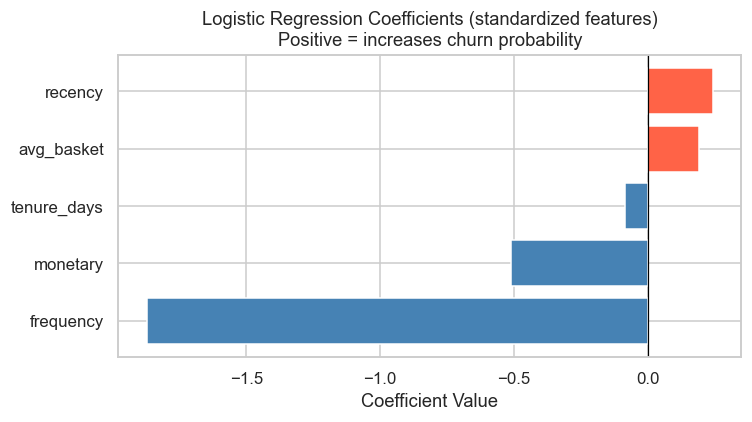

In [23]:
# Appendix A2 - Logistic Regression

# coefficient Plot
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coefficient': lr.coef_[0]
}).sort_values('coefficient')

colors = ['tomato' if c > 0 else 'steelblue' for c in coef_df['coefficient']]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(coef_df['feature'], coef_df['coefficient'], color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Logistic Regression Coefficients (standardized features)\nPositive = increases churn probability')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()


=== Model Comparison Summary ===


,AUC-ROC,F1 Score,Precision,Recall
Model,,,,
Baseline RF,0.7238,0.6378,0.5924,0.6906
Tuned RF,0.7363,0.6446,0.5793,0.7265
Logistic Regression,0.7313,0.6651,0.5818,0.7762


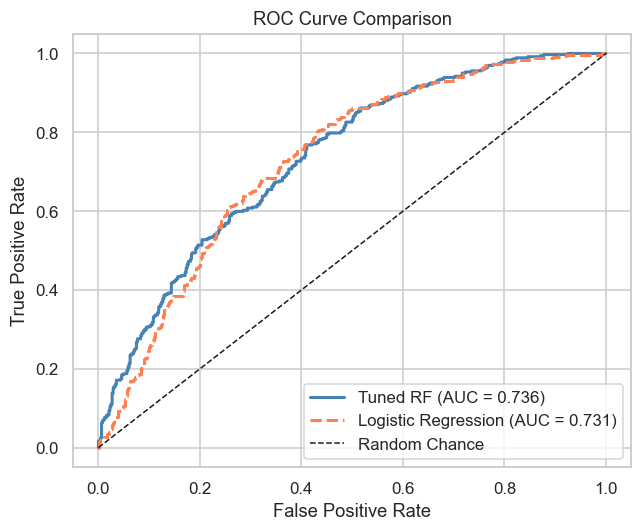

In [24]:
# Appendix A3 - Logistic Regression

# model comparison summary
comparison = pd.DataFrame({
    'Model': ['Baseline RF', 'Tuned RF', 'Logistic Regression'],
    'AUC-ROC': [
        roc_auc_score(y_test, y_proba_base),
        auc_rf,
        auc_lr
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_base),
        f1_rf,
        f1_score(y_test, y_pred_lr)
    ],
    'Precision': [
        precision_score(y_test, y_pred_base),
        prec_rf,
        precision_score(y_test, y_pred_lr)
    ],
    'Recall': [
        recall_score(y_test, y_pred_base),
        rec_rf,
        recall_score(y_test, y_pred_lr)
    ]
})

print('=== Model Comparison Summary ===')
display(comparison.set_index('Model').round(4))

# ROC overlay
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color='steelblue', lw=2, label=f'Tuned RF (AUC = {auc_rf:.3f})')
ax.plot(fpr_lr, tpr_lr, color='coral', lw=2, linestyle='--', label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Chance')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison')
ax.legend()
plt.tight_layout()
plt.show()
